In [3]:
from dotenv import load_dotenv
import os

In [4]:
load_dotenv()
data_path = os.getenv("DATA_PATH")

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv(data_path)

df.replace("?", np.nan, inplace=True)

for col in ['workclass', 'occupation', 'native.country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.drop_duplicates(inplace=True)

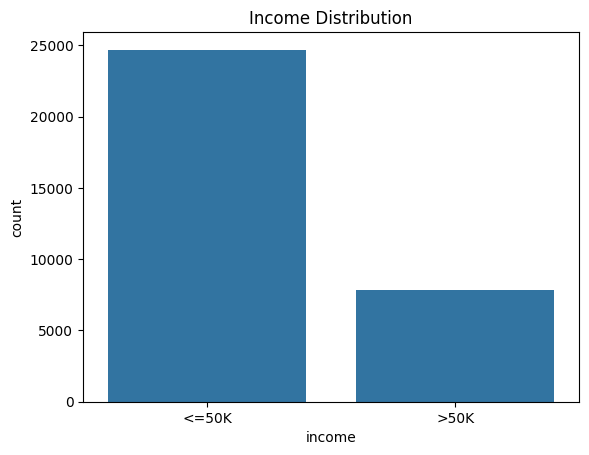

In [8]:
plt.figure()
sns.countplot(data=df,x="income")
plt.title("Income Distribution")
plt.show()


In [9]:
df_encoded = df.copy()

# Encode all categorical columns
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])


In [10]:
X = df_encoded.drop("income", axis=1)
y = df_encoded["income"]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [12]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())


Before SMOTE:
 income
0    19758
1     6271
Name: count, dtype: int64

After SMOTE:
 income
0    19758
1    19758
Name: count, dtype: int64
